MODEL OCULTO DE MARKOV

Los modelos ocultos de markov posen la propiedad de buscar esados donde



Problemas de trafico usando cadenas de markov
Contexto: Predicción del estado del tráfico basándose en velocidad promedio observada.
Estados Ocultos: Tráfico Fluido, Moderado, Congestionado
Observaciones: Velocidad (Alta, Media, Baja)

Matriz de transición:
- Fluido → [Fluido: 0.7, Moderado: 0.25, Congestionado: 0.05]
- Moderado → [Fluido: 0.3, Moderado: 0.5, Congestionado: 0.2]
- Congestionado → [Fluido: 0.1, Moderado: 0.4, Congestionado: 0.5]

Matriz de emisión:
- Fluido → [Alta: 0.8, Media: 0.15, Baja: 0.05]
- Moderado → [Alta: 0.2, Media: 0.6, Baja: 0.2]
- Congestionado → [Alta: 0.05, Media: 0.25, Baja: 0.7]

Distribución inicial: [Fluido: 0.5, Moderado: 0.3, Congestionado: 0.2]


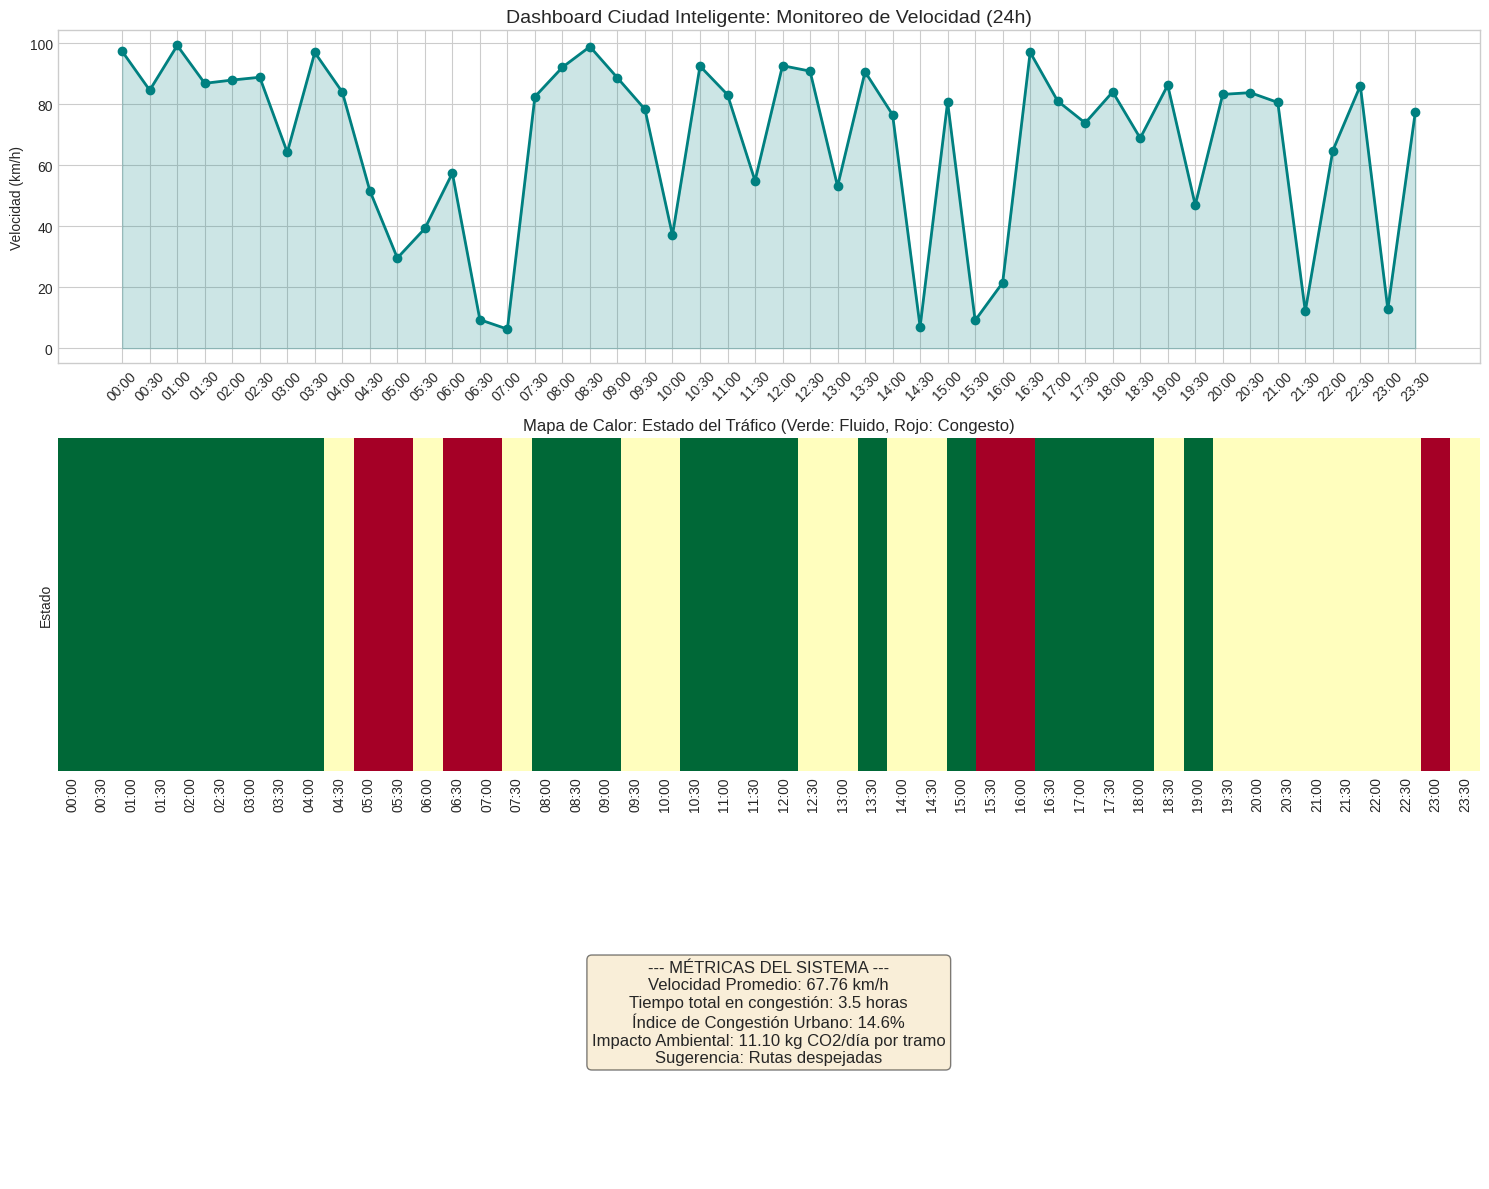

    Hora  Velocidad_kmh Semaforo
0  00:00      97.317800        🟢
1  00:30      84.593623        🟢
2  01:00      99.260502        🟢
3  01:30      86.851173        🟢
4  02:00      87.926191        🟢
5  02:30      88.834421        🟢
6  03:00      64.217272        🟢
7  03:30      96.958056        🟢
8  04:00      83.966716        🟢
9  04:30      51.663953        🟡


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Configuración de estilo
plt.style.use('seaborn-v0_8-whitegrid')

class TrafficHMM:
    def __init__(self):
        # Definición de Estados y Observaciones
        self.states = ['Fluido', 'Moderado', 'Congestionado']
        self.observations = ['Alta', 'Media', 'Baja']

        # Probabilidades Iniciales (Pi)
        self.pi = np.array([0.5, 0.3, 0.2])

        # Matriz de Transición (A)
        # Filas: Estado actual, Columnas: Siguiente estado
        self.A = np.array([
            [0.7, 0.25, 0.05],  # Fluido
            [0.3, 0.5, 0.2],   # Moderado
            [0.1, 0.4, 0.5]    # Congestionado
        ])

        # Matriz de Emisión (B)
        # Filas: Estado oculto, Columnas: Observación (Velocidad)
        self.B = np.array([
            [0.8, 0.15, 0.05], # Fluido -> [Alta, Media, Baja]
            [0.2, 0.6, 0.2],   # Moderado
            [0.05, 0.25, 0.7]  # Congestionado
        ])

    def simulate(self, steps=48):
        """Genera la simulacion con numero de pasos"""
        current_state = np.random.choice(len(self.states), p=self.pi)
        state_history = []
        obs_history = []
        velocities = []

        for _ in range(steps):
            state_history.append(current_state)

            # Generar observación basada en el estado actual, escojiendo uno al azar
            obs = np.random.choice(len(self.observations), p=self.B[current_state])
            obs_history.append(obs)

            # Generar velocidad física en km/h
            if obs == 0: v = np.random.uniform(80, 100)  # Alta
            elif obs == 1: v = np.random.uniform(40, 80) # Media
            else: v = np.random.uniform(5, 40)           # Baja
            velocities.append(v)

            # Transición al siguiente estado
            current_state = np.random.choice(len(self.states), p=self.A[current_state])

        return state_history, obs_history, velocities

    def viterbi(self, obs_sequence):
        """Algoritmo de Viterbi para predecir la secuencia más probable de estados buscando el estado mas probable dado las cadenas"""
        #dado o buscando el estado del modelo con mayor probabilidad en cada instante
        T = len(obs_sequence)
        N = len(self.states)
        delta = np.zeros((T, N))
        psi = np.zeros((T, N), dtype=int)

        delta[0] = self.pi * self.B[:, obs_sequence[0]]

        for t in range(1, T):
            for j in range(N):
                prob = delta[t-1] * self.A[:, j] * self.B[j, obs_sequence[t]]
                delta[t, j] = np.max(prob)
                psi[t, j] = np.argmax(prob)

        states_path = np.zeros(T, dtype=int)
        states_path[-1] = np.argmax(delta[-1])
        for t in range(T-2, -1, -1):
            states_path[t] = psi[t+1, states_path[t+1]]

        return states_path

# 1. Ejecutar Simulación
hmm = TrafficHMM()
steps = 48
states_idx, obs_idx, velocities = hmm.simulate(steps)

# 2. Preparación de Datos
times = [(datetime(2024, 1, 1, 0, 0) + timedelta(minutes=30*i)).strftime('%H:%M') for i in range(steps)]
df = pd.DataFrame({
    'Hora': times,
    'Estado_Real': [hmm.states[i] for i in states_idx],
    'Velocidad_kmh': velocities,
    'Semaforo': ['🟢' if s == 0 else '🟡' if s == 1 else '🔴' for s in states_idx]
})

# 3. Métricas y Análisis
avg_speed = df['Velocidad_kmh'].mean()
congested_time = len(df[df['Estado_Real'] == 'Congestionado']) * 30 / 60 # Horas
peak_hours = df[df['Estado_Real'] == 'Congestionado']['Hora'].tolist()
# Índice de congestión: (Tiempo en congestión / Tiempo total) * 100
congestion_index = (df['Estado_Real'] == 'Congestionado').mean() * 100
# Emisiones CO2 estimadas (simplificado: Congestión emite 3x más que fluido)
emissions = df['Estado_Real'].map({'Fluido': 150, 'Moderado': 250, 'Congestionado': 450}).sum() / 1000

# 4. Dashboard de Visualización
fig = plt.figure(figsize=(15, 12))

# Subplot 1: Velocidad
plt.subplot(3, 1, 1)
plt.plot(df['Hora'], df['Velocidad_kmh'], marker='o', color='teal', linewidth=2)
plt.fill_between(df['Hora'], df['Velocidad_kmh'], alpha=0.2, color='teal')
plt.title('Dashboard Ciudad Inteligente: Monitoreo de Velocidad (24h)', fontsize=14)
plt.ylabel('Velocidad (km/h)')
plt.xticks(rotation=45)

# Subplot 2: Mapa de calor de estados
plt.subplot(3, 1, 2)
state_matrix = np.array(states_idx).reshape(1, -1)
sns.heatmap(state_matrix, cmap='RdYlGn_r', cbar=False, yticklabels=['Estado'])
plt.title('Mapa de Calor: Estado del Tráfico (Verde: Fluido, Rojo: Congesto)')
plt.xticks(np.arange(48)+0.5, times, rotation=90)

# Subplot 3: Tabla de Métricas
plt.subplot(3, 1, 3)
plt.axis('off')
metricas_text = (
    f"--- MÉTRICAS DEL SISTEMA ---\n"
    f"Velocidad Promedio: {avg_speed:.2f} km/h\n"
    f"Tiempo total en congestión: {congested_time} horas\n"
    f"Índice de Congestión Urbano: {congestion_index:.1f}%\n"
    f"Impacto Ambiental: {emissions:.2f} kg CO2/día por tramo\n"
    f"Sugerencia: { 'Tomar rutas alternas (Av. Periférica)' if congestion_index > 20 else 'Rutas despejadas' }"
)
plt.text(0.5, 0.5, metricas_text, fontsize=12, ha='center', va='center',
         bbox=dict(boxstyle="round", facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# Imprimir reporte en consola
print(df[['Hora', 'Velocidad_kmh', 'Semaforo']].head(10))